In [1]:
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon, shapiro, spearmanr
import numpy as np

In [2]:
# --- 1. Load the CSV file ---
df = pd.read_csv("E066 and HepG2 Results.csv")

In [3]:
df

,id,histone_marks,number_of_histones,E066_val_acc,E066_test_acc,E066_rank_by_test_acc,HepG2_val_acc,HepG2_test_acc,HepG2_rank_by_test_acc
0,1,H3K4me3-H3K9ac-H3K9me3-H3K27ac-H3K27me3,5,76.7244,76.17,12,70.6105,70.86,2
1,2,H3K4me3-H3K9ac-H3K27ac-H3K27me3,4,76.7728,76.65,5,70.2940,69.88,18
2,3,H3K4me3-H3K9ac-H3K9me3-H3K27ac,4,76.7842,76.80,4,70.1595,70.14,11
3,4,H3K4me3-H3K9ac-H3K9me3-H3K27me3,4,76.1601,76.25,10,70.2557,70.94,1
4,5,H3K4me3-H3K9me3-H3K27ac-H3K27me3,4,76.6654,77.34,1,70.1946,69.30,26
5,6,H3K9ac-H3K9me3-H3K27ac-H3K27me3,4,76.5195,76.52,7,70.2502,70.61,4
6,7,H3K4me3-H3K27ac-H3K27me3,3,76.4883,76.01,16,70.2838,70.17,10
7,8,H3K4me3-H3K9ac-H3K27ac,3,76.6717,76.07,14,70.0775,69.54,23
8,9,H3K4me3-H3K9ac-H3K27me3,3,75.7109,76.16,13,70.4363,70.52,5
9,10,H3K4me3-H3K9ac-H3K9me3,3,75.8993,76.22,11,69.8092,69.10,28


In [4]:
# --- 2. Compute the differences ---
df['diff'] = df['E066_test_acc'] - df['HepG2_test_acc']

In [5]:
df

,id,histone_marks,number_of_histones,E066_val_acc,E066_test_acc,E066_rank_by_test_acc,HepG2_val_acc,HepG2_test_acc,HepG2_rank_by_test_acc,diff
0,1,H3K4me3-H3K9ac-H3K9me3-H3K27ac-H3K27me3,5,76.7244,76.17,12,70.6105,70.86,2,5.31
1,2,H3K4me3-H3K9ac-H3K27ac-H3K27me3,4,76.7728,76.65,5,70.2940,69.88,18,6.77
2,3,H3K4me3-H3K9ac-H3K9me3-H3K27ac,4,76.7842,76.80,4,70.1595,70.14,11,6.66
3,4,H3K4me3-H3K9ac-H3K9me3-H3K27me3,4,76.1601,76.25,10,70.2557,70.94,1,5.31
4,5,H3K4me3-H3K9me3-H3K27ac-H3K27me3,4,76.6654,77.34,1,70.1946,69.30,26,8.04
5,6,H3K9ac-H3K9me3-H3K27ac-H3K27me3,4,76.5195,76.52,7,70.2502,70.61,4,5.91
6,7,H3K4me3-H3K27ac-H3K27me3,3,76.4883,76.01,16,70.2838,70.17,10,5.84
7,8,H3K4me3-H3K9ac-H3K27ac,3,76.6717,76.07,14,70.0775,69.54,23,6.53
8,9,H3K4me3-H3K9ac-H3K27me3,3,75.7109,76.16,13,70.4363,70.52,5,5.64
9,10,H3K4me3-H3K9ac-H3K9me3,3,75.8993,76.22,11,69.8092,69.10,28,7.12


In [18]:
# --- 3. Check normality of the differences ---
stat, p_normality = shapiro(df['diff'])
print(f"Shapiro–Wilk p-value (normality): {p_normality:}")

if p_normality < 0.05:
    print("⚠️ Differences are NOT normally distributed → use Wilcoxon test.")
else:
    print("✅ Differences are normally distributed → use Paired t-test.")

Shapiro–Wilk p-value (normality): 5.106048447687467e-07
⚠️ Differences are NOT normally distributed → use Wilcoxon test.


In [7]:
# --- 4. Statistical significance test ---
if p_normality < 0.05:
    stat_test, p_value = wilcoxon(df['E066_test_acc'], df['HepG2_test_acc'])
    test_used = "Wilcoxon Signed-Rank Test"
else:
    stat_test, p_value = ttest_rel(df['E066_test_acc'], df['HepG2_test_acc'])
    test_used = "Paired t-test"

print(f"\n{test_used} p-value: {p_value}")


Wilcoxon Signed-Rank Test p-value: 1.91612681359325e-06


In [8]:
# --- 5. Effect size (Cohen's d for paired samples) ---
mean_diff = np.mean(df['diff'])
std_diff = np.std(df['diff'], ddof=1)
cohen_d = mean_diff / std_diff
print(f"Cohen's d (effect size): {cohen_d:.3f}")


Cohen's d (effect size): 2.030


In [9]:
# --- 6. Correlation between datasets ---
rho, p_corr = spearmanr(df['E066_test_acc'], df['HepG2_test_acc'])
print(f"\nSpearman correlation: {rho:.3f} (p = {p_corr:.4f})")


Spearman correlation: 0.298 (p = 0.1040)


In [10]:
# --- 7. Optional summary ---
print("\nSummary:")
print(df[['E066_test_acc', 'HepG2_test_acc', 'diff']].describe())


Summary:
       E066_test_acc  HepG2_test_acc       diff
count      31.000000       31.000000  31.000000
mean       74.363548       69.206774   5.156774
std         4.929661        2.668506   2.539666
min        56.840000       59.540000  -3.260000
25%        75.180000       69.515000   5.215000
50%        76.010000       69.930000   5.670000
75%        76.285000       70.240000   6.555000
max        77.340000       70.940000   8.040000


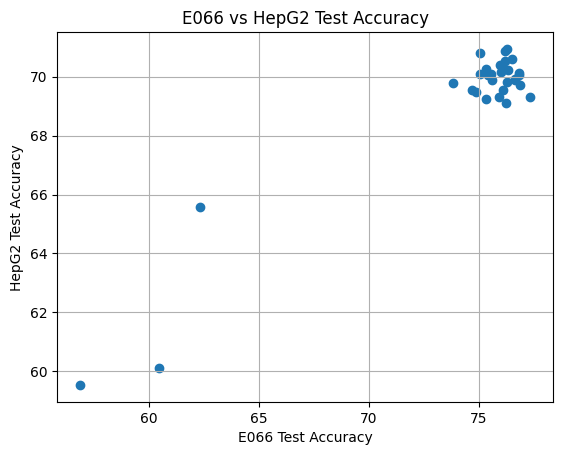

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['E066_test_acc'], df['HepG2_test_acc'])
plt.xlabel('E066 Test Accuracy')
plt.ylabel('HepG2 Test Accuracy')
plt.title('E066 vs HepG2 Test Accuracy')
plt.grid(True)
plt.show()